<a href="https://colab.research.google.com/github/billalsohail/ML4MC/blob/main/Atom%20counts%20attempt%20Joseph.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# RUN THIS CELL 

! pip install dscribe  # Downloads needed modules
! pip install ase

# -------------------------------------------------------

import io
from datetime import datetime
import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import requests
from ase.io import read
from sklearn.model_selection import train_test_split

def download_published_data():
  """Downloads and unzips data folder.
  """


  start = datetime.now()
  print(start)
  r = requests.get('https://people.bath.ac.uk/crh53/m1507656.zip')
  zipped = zipfile.ZipFile(io.BytesIO(r.content))
  zipped.extractall('')
  finish = datetime.now()
  print(finish)
  print(finish - start)

def xyz_str_to_atoms(xyz_str):
  """
  Convert a xyz file to an ASE atoms object via in-memory file (StringIO).
  """
  f = io.StringIO()
  f.write(xyz_str)
  f.seek(0)
  atoms = read(f, format="xyz")
  return atoms

# -------------------------------------------------------

print('Downloading data...')
download_published_data()  # downloads needed data
% cd m1507656

from helpers import get_level  # needs to go here as wont have been downloaded earlier in

print('Loading data...')
df = pd.read_json('df_5k.json', orient='split')

print('Generating `ase.Atoms` objects...')
df['atoms'] = df['xyz_pbe_relaxed'].apply(xyz_str_to_atoms)

print('Extracting HOMO, LUMO, BANDGAP from data...')
df['HOMO'] = df.apply(lambda row: get_level(row, level_type='HOMO', subset='GOWO_at_PBE0_cbs'), axis=1)
df['LUMO'] = df.apply(lambda row: get_level(row, level_type='LUMO', subset='GOWO_at_PBE0_cbs'), axis=1)
df['BG'] = df['LUMO'] - df['HOMO']
print('~ 2300 molecules do not have LUMO energy levels for this or any other `GOWO` level of theory.')

print('Splitting data set...')
train, test = train_test_split(df, test_size=0.2, random_state=20210817)
train_atoms, test_atoms = train['atoms'].to_list(), test['atoms'].to_list()

print('Data Processing Complete')
print('#', '-'*119)

     |████████████████████████████████| 143 kB 8.3 MB/s 
  Using cached pybind11-2.7.1-py2.py3-none-any.whl (200 kB)
     |████████████████████████████████| 2.2 MB 42.2 MB/s 
     |████████████████████████████████| 76 kB 5.1 MB/s 
  Created wheel for dscribe: filename=dscribe-1.1.0-cp37-cp37m-linux_x86_64.whl size=4339750 sha256=fb5083030d9d77176a41e6826b110c489579f4d10d74184f71f04b61b8c9699e
  Stored in directory: /root/.cache/pip/wheels/05/f8/a6/c5328c447d56d1efed920c372cbd0086ac1e01de1b5adaa9db
Successfully built dscribe
2021-08-24 06:05:55.796117
2021-08-24 06:06:33.634737
0:00:37.838620
/content/m1507656
Loading data...
Generating `ase.Atoms` objects...
Extracting HOMO, LUMO, BANDGAP from data...
err FOVWES
err FOWGIH
err FOYJUZ
err FUNBUL
err FUPZAR
err FUXFAG
err GANSAQ
err GAQCEI
err NUFRUB
err GEPHEO
err GERGOB
err GETBUD
err GEVDAN
err GEYQAC
err GIDQAN
err GIMPUO
err GISBOA
err NUNJAH
err NUNJEL
err NUNKEM
err GODBUW
err NUQCIM
err WEBWUV
err GUCLIA
err GUMBEV
err HACGAT
err

In [3]:
from sklearn.kernel_ridge import KernelRidge

class KernelRidgeRegressor(KernelRidge):
  """Class that performs target normalisation as part of the fit and predict
  methods.
  """

  def fit(self, X, y):
    self.mu = np.mean(y_train)
    y_tr = (y - self.mu) / self.mu
    super().fit(X, y_tr)

  def predict(self, X):
    pred = super().predict(X)
    pred_tr = (pred * self.mu) + self.mu
    return pred_tr

In [4]:
df.columns.tolist()

['refcode_csd',
 'canonical_smiles',
 'inchi',
 'number_of_atoms',
 'xyz_pbe_relaxed',
 'energies_occ_pbe',
 'energies_occ_pbe0_vac_tier2',
 'energies_occ_pbe0_water',
 'energies_occ_pbe0_vac_tzvp',
 'energies_occ_pbe0_vac_qzvp',
 'energies_occ_gw_tzvp',
 'energies_occ_gw_qzvp',
 'cbs_occ_gw',
 'energies_unocc_pbe',
 'energies_unocc_pbe0_vac_tier2',
 'energies_unocc_pbe0_water',
 'energies_unocc_pbe0_vac_tzvp',
 'energies_unocc_pbe0_vac_qzvp',
 'energies_unocc_gw_tzvp',
 'energies_unocc_gw_qzvp',
 'cbs_unocc_gw',
 'total_energy_pbe',
 'total_energy_pbe0_vac_tier2',
 'total_energy_pbe0_water',
 'total_energy_pbe0_vac_tzvp',
 'total_energy_pbe0_vac_qzvp',
 'hirshfeld_pbe',
 'hirshfeld_pbe0_vac_tier2',
 'hirshfeld_pbe0_water',
 'atoms',
 'HOMO',
 'LUMO',
 'BG']

In [5]:
df.head(10)

,refcode_csd,canonical_smiles,inchi,number_of_atoms,xyz_pbe_relaxed,energies_occ_pbe,energies_occ_pbe0_vac_tier2,energies_occ_pbe0_water,energies_occ_pbe0_vac_tzvp,energies_occ_pbe0_vac_qzvp,energies_occ_gw_tzvp,energies_occ_gw_qzvp,cbs_occ_gw,energies_unocc_pbe,energies_unocc_pbe0_vac_tier2,energies_unocc_pbe0_water,energies_unocc_pbe0_vac_tzvp,energies_unocc_pbe0_vac_qzvp,energies_unocc_gw_tzvp,energies_unocc_gw_qzvp,cbs_unocc_gw,total_energy_pbe,total_energy_pbe0_vac_tier2,total_energy_pbe0_water,total_energy_pbe0_vac_tzvp,total_energy_pbe0_vac_qzvp,hirshfeld_pbe,hirshfeld_pbe0_vac_tier2,hirshfeld_pbe0_water,atoms,HOMO,LUMO,BG
10,FOVWES,COC(=O)[C@H](n1c(=S)sc(c1CC)C)C\t\n,InChI=1S/C10H15NO2S2/c1-5-8-7(3)15-10(14)11(8)...,30,30\n\nS 36.75934695 47.20389183 ...,"[-2412.24039, -2409.98986, -512.34265, -510.73...","[-2438.90946, -2436.50894, -524.75994, -523.16...","[-2439.12701, -2436.92988, -525.03583, -523.66...","[-2440.78485, -2438.41749, -524.75752, -523.11...","[-2439.03194, -2436.67645, -524.81876, -523.19...","[-29.1271, -24.9308, -24.2622, -23.3517, -22.6...","[-29.2628, -25.0892, -24.3714, -23.5214, -22.8...","[-29.36351, -25.20675, -24.45244, -23.64734, -...","[-1.79638, -1.16331, -0.8942200000000001, -0.7...","[-1.00989, -0.28629000000000004, -0.0223]","[-1.3107600000000001, -0.37236]","[-0.94898, -0.04764]","[-1.01171, -0.17985]",0.5708,0.2503,0.01245,-37957.125810,-37959.436725,-37959.781206,-37955.151866,-37958.392015,"[0.10253628000000001, 0.00547996, -0.012183910...","[0.09987054000000001, 0.02339617, -0.02340592,...","[0.10696537, 0.01796455, -0.01695311, 0.038783...","(Atom('S', [36.75934695, 47.20389183, 45.77859...",-7.52433,NaN,NaN
13,FOWGIH,O=P1Oc2ccccc2N(c2c(O1)cccc2)c1ccccc1O\t\n,InChI=1S/C18H14NO4P/c20-16-10-4-1-7-13(16)19-1...,38,38\n\nH 12.71064531 19.89742093 ...,"[-2091.34232, -512.89603, -512.82777, -511.071...","[-2116.2313, -525.35737, -525.2753, -523.39362...","[-2116.36062, -525.43865, -525.32768, -524.020...","[-2117.92912, -525.37336, -525.29157, -523.373...","[-2116.40386, -525.41418, -525.33251, -523.431...","[-29.1772, -28.1356, -25.4081, -25.0932, -24.3...","[-29.3487, -28.3072, -25.5324, -25.2152, -24.5...","[-29.49661, -28.4552, -25.63961, -25.32042, -2...","[-1.95194, -1.7190400000000001, -1.4932, -1.40...","[-1.0777700000000001, -0.8311200000000001, -0....","[-1.02904, -0.81579, -0.7339100000000001, -0.5...","[-1.0339, -0.7883600000000001, -0.568000000000...","[-1.07954, -0.8363700000000001, -0.61953, -0.5...",0.4221,0.1608,-0.06456,-37897.107973,-37898.626863,-37898.981311,-37894.899503,-37897.489935,"[0.05218846, 0.05394222, -0.03803773, -0.04503...","[0.05369862, 0.05568369, -0.03772409, -0.04654...","[0.06260278, 0.06495193, -0.037864499999999995...","(Atom('H', [12.71064531, 19.89742093, 24.67978...",-7.59805,NaN,NaN
16,FOWZUN01,COc1cc(/C=N/NC(=O)C)ccc1OC\t\n,InChI=1S/C11H14N2O3/c1-8(14)13-12-7-9-4-5-10(1...,30,30\n\nO 52.68107801 40.00990379 ...,"[-512.23333, -512.0378, -510.09269, -382.82501...","[-524.54893, -524.35885, -522.49983, -393.7126...","[-524.74742, -524.66529, -523.1113, -393.88073...","[-524.53793, -524.34385, -522.42474, -393.6580...","[-524.60145, -524.40947, -522.51429, -393.7501...","[-29.3566, -25.1244, -24.6401, -23.5505, -22.0...","[-29.457, -25.3739, -24.8026, -23.0988, -22.44...","[-29.53444, -25.56633, -24.92793, -22.75042, -...","[-2.18158, -0.9446100000000001, -0.55918, -0.3...","[-1.38562, -0.050980000000000004]","[-1.62935, -0.25269]",[-1.3227600000000002],"[-1.37606, -0.0553]",[0.1763],[-0.0988],[-0.31098000000000003],-20757.356135,-20757.760932,-20758.252762,-20756.008159,-20757.333450,"[-0.0919376, -0.09781358, 0.05549081, -0.06736...","[-0.11444561, -0.11968959, 0.06339492000000001...","[-0.13184671, -0.13691553, 0.0551235, -0.07349...","(Atom('O', [52.68107801, 40.00990379, 54.18280...",-7.56882,-0.31098,7.25784
24,FOYJUZ,CC(=O)c1c(O)cc2c(c1C(F)(F)F)CCCCC2\t\n,InChI=1S/C14H15F3O2/c1-8(18)12-11(19)7-9-5-3-2...,34,34\n\nC 31.38645310 35.92076832 

In [6]:
df_subset = (df[['refcode_csd', 'canonical_smiles', 'number_of_atoms','total_energy_pbe', 'HOMO']])
df_subset

,refcode_csd,canonical_smiles,number_of_atoms,total_energy_pbe,HOMO
10,FOVWES,COC(=O)[C@H](n1c(=S)sc(c1CC)C)C\t\n,30,-37957.125810,-7.52433
13,FOWGIH,O=P1Oc2ccccc2N(c2c(O1)cccc2)c1ccccc1O\t\n,38,-37897.107973,-7.59805
16,FOWZUN01,COc1cc(/C=N/NC(=O)C)ccc1OC\t\n,30,-20757.356135,-7.56882
24,FOYJUZ,CC(=O)c1c(O)cc2c(c1C(F)(F)F)CCCCC2\t\n,34,-27015.705595,-8.55279
38,FPFAZP,CN1P(F)(F)(c2c(F)c(F)c(c(c2F)F)F)N(P1(F)(F)c1c...,38,-74312.812778,-9.69865
...,...,...,...,...,...
61457,VIGDOE,COC(=O)c1c(c(C(=O)OC)c(c(c1C(C)(C)C)C(=O)OC)C(...,66,-37759.078750,-8.27565
61458,FOMSEG,O=C(c1ccccc1O)N/N=C/c1ccc(c(c1)Cl)Cl\t\n,30,-46914.426056,-8.13569
61473,FOPCOC,C1=CC=C2C[C]([CH]1)[C]1[CH]C=CC=C(C1)CC2\t\n,32,-16847.126386,-7.16008
61478,VINMOV,Cc1ccc(cc1)S(=O)(=O)N[C@H](C(=O)N1C(=O)OC[C@@H...,57,-134363.234235,-8.94442


In [111]:
from sklearn.kernel_ridge import KernelRidge

class KernelRidgeRegressor(KernelRidge):
  """Class that performs target normalisation as part of the fit and predict
  methods.
  """

  def fit(self, X, y):
    self.mu = np.mean(y_train)
    y_tr = (y - self.mu) / self.mu
    super().fit(X, y_tr)

  def predict(self, X):
    pred = super().predict(X)
    pred_tr = (pred * self.mu) + self.mu
    return pred_tr

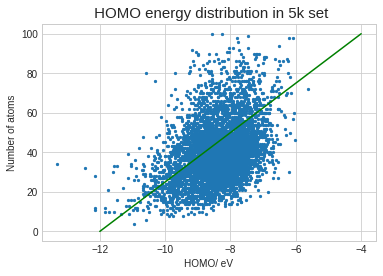

In [114]:
plt.plot((-12,-4), (0,100), c='green')
plt.scatter(df_subset["HOMO"], df_subset["number_of_atoms"], s=5)
plt.xlabel("HOMO/ eV")
plt.ylabel("Number of atoms")
plt.title(" HOMO energy distribution in 5k set", fontsize=15)
plt.show()

In [8]:
dataframe = df
df_name = '5k'

count_abs_occ = dict()    
count_molecules = dict()  
occ_per_molecule = dict() 
na_array= []
num_nonh_array = []

for i,row in dataframe.iterrows():
    types = [] 
    xyz = row.xyz_pbe_relaxed.split("\n")
    na = xyz[0]
    na_array.append(na)
    for i in range(int(na)):
        al = xyz[i+2]
        atom, x, y, z = al.split()
        types.append(atom)
    
    # count total number of times that a certain element occurs in dataset
    for element in types:
        if element in count_abs_occ:
            count_abs_occ[element] += 1
        else:
            count_abs_occ[element] = 1
            
    # count number of molecules that contain a certain element 
    for element in list(set(types)):
        if element in count_molecules:
            count_molecules[element] += 1
        else:
            count_molecules[element] = 1 
    
    # count number of "heavy" (non-H) atoms in a molecule
    num_nonh = sum(x != 'H' for x in types)
    num_nonh_array.append(num_nonh)

In [9]:
## compute size distribution of molecules

a = np.array(na_array)
na_list = a.tolist()
na_list = [int(i) for i in na_list]
max_na = max(na_list)

na_array = np.asarray(na_list)
y = np.bincount(na_array)
ii = np.nonzero(y)[0]
number_of_atoms_index = np.array(list(zip(ii, y[ii])))
number_of_atoms_index = number_of_atoms_index.T
num_atoms = number_of_atoms_index[0]
count = number_of_atoms_index[1]

## bins for histogram
bins = np.arange(1, max_na+1)


In [10]:
print('The largest molecule of the 5k set has %i atoms.' % max_na)
print("On average, the molecular size is %f atoms, with an average of %f heavy (non-H) atoms." 
      %(na_array.mean(), np.asarray(num_nonh_array).mean()))
print("The molecular size distribution has a standard deviation of %f and a variance of %f." 
      %(na_array.std(), na_array.var()))

The largest molecule of the 5k set has 100 atoms.
On average, the molecular size is 40.076541 atoms, with an average of 22.027295 heavy (non-H) atoms.
The molecular size distribution has a standard deviation of 14.917565 and a variance of 222.533748.


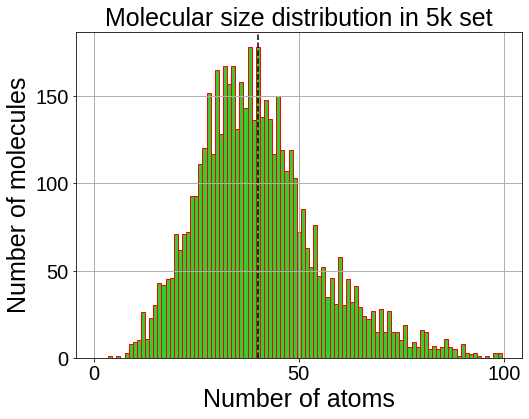

In [11]:
ig, ax = plt.subplots(1,1, figsize=(8,6))
plt.style.use('seaborn-whitegrid')
ax.hist(na_list, bins=bins, align='left', color='limegreen', edgecolor='red')
plt.axvline(x=na_array.mean(), linestyle='--', color='k')
ax.grid(linewidth=1)
plt.tick_params(labelsize=40)
plt.tick_params(labelsize=40)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.xlabel('Number of atoms', fontsize=25)
plt.ylabel('Number of molecules', fontsize=25)
plt.title("Molecular size distribution in 5k set", fontsize=25)
#plt.xlim(0,120)
#fig.savefig('size_distribution_%s.png' %df_name, dpi=200, bbox_inches="tight")
plt.show()

In [134]:
atomic_numbers = df['atoms'].apply(lambda x: x.numbers)
unique_atomic_numbers = set([a for b in atomic_numbers for a in b])
max_num_atoms = atomic_numbers.apply(len).max()

print(unique_atomic_numbers)
print(max_num_atoms)

{1, 34, 35, 33, 5, 6, 7, 8, 9, 3, 14, 15, 16, 17, 53}
100


In [135]:
X_train = train['number_of_atoms'].values.reshape(-1,1)
X_train

array([[28],
       [31],
       [40],
       ...,
       [34],
       [24],
       [31]])

In [118]:
X_test = test['number_of_atoms'].values.reshape(-1,1)
X_test

array([[30],
       [27],
       [42],
       ...,
       [30],
       [30],
       [ 9]])

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.kernel_ridge import KernelRidge
from sklearn.metrics import mean_squared_error, r2_score

In [146]:
y_train = train['HOMO'].values  # extract target value from dataframe

In [147]:
# split the training data again into training and cross validation sets
X_tr, X_cv, y_tr, y_cv = train_test_split(X_train, y_train, test_size=0.2, random_state=1)

In [148]:
model = KernelRidge(kernel='laplacian', alpha=1.0, gamma=0.01)  # gauscian or laplacian

In [149]:
model.fit(X_tr, y_tr)

KernelRidge(alpha=1.0, coef0=1, degree=3, gamma=0.01, kernel='laplacian',
            kernel_params=None)

In [150]:
y_pred_tr = model.predict(X_tr)
y_pred_cv = model.predict(X_cv)

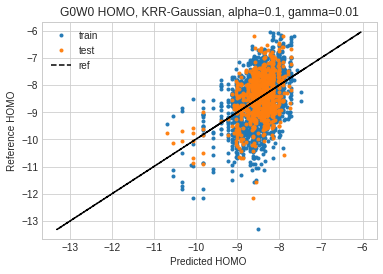

In [133]:
plt.title("G0W0 HOMO, KRR-Gaussian, alpha=0.1, gamma=0.01")
plt.plot(y_pred_tr, y_tr, '.', alpha=11, label='train')
plt.plot(y_pred_cv, y_cv, '.', alpha=11, label='test')
plt.plot(y_tr, y_tr, 'k--', label='ref')
plt.xlabel('Predicted HOMO ')
plt.ylabel('Reference HOMO')
plt.legend()
plt.show()


In [95]:
for s, pred, ref in zip(('train', 'cv'), (y_pred_tr, y_pred_cv), (y_tr, y_cv)):
  mse = mean_squared_error(ref, pred)
  r2 = r2_score(ref, pred)

  print(F'{s} : mse={mse:.3f}, r2={r2:.3f}')

train : mse=0.565, r2=0.179
cv : mse=0.531, r2=0.173


In [96]:
print("Mean square error on test set: %0.3f eV" % mean_squared_error(y_pred_cv, y_cv))

Mean square error on test set: 0.531 eV


In [97]:
print("Mean absolute error on test set: %0.3f eV" %(np.abs(y_pred_cv-y_cv)).mean())

Mean absolute error on test set: 0.589 eV


In [23]:
from sklearn.model_selection import GridSearchCV

In [137]:
alpha = np.logspace(-2, 2, 5)
gamma = np.logspace(-2, 2, 5)
kernel = 'rbf'
cv_number = 5
scoring_function = 'neg_mean_absolute_error' 
grid_search = GridSearchCV(KernelRidge(), 
                           [{'kernel':[kernel],'alpha': alpha, 'gamma': gamma}], 
                           cv = cv_number, 
                           scoring = scoring_function,
                           verbose=1000)

from datetime import datetime
start = datetime.now()

grid_search.fit(X_train, y_train)

finish = datetime.now()
total_time = finish - start 
print("It took how long?", total_time)

Fitting 5 folds for each of 25 candidates, totalling 125 fits
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[CV] alpha=0.01, gamma=0.01, kernel=rbf ..............................
[CV] . alpha=0.01, gamma=0.01, kernel=rbf, score=-0.601, total=   1.4s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    1.4s remaining:    0.0s
[CV] alpha=0.01, gamma=0.01, kernel=rbf ..............................
[CV] . alpha=0.01, gamma=0.01, kernel=rbf, score=-0.572, total=   1.3s
[Parallel(n_jobs=1)]: Done   2 out of   2 | elapsed:    2.7s remaining:    0.0s
[CV] alpha=0.01, gamma=0.01, kernel=rbf ..............................
[CV] . alpha=0.01, gamma=0.01, kernel=rbf, score=-0.604, total=   1.3s
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    4.0s remaining:    0.0s
[CV] alpha=0.01, gamma=0.01, kernel=rbf ..............................
[CV] . alpha=0.01, gamma=0.01, kernel=rbf, score=-0.589, total=   1.3s
[Parallel(n_jobs=1)]: Done   4 out of   4 | elaps

In [138]:
optimum = grid_search.best_estimator_

print(F'Optimal alpha value is: {optimum.alpha}')
print(F'Optimal gamma value is: {optimum.gamma}')

Optimal alpha value is: 0.1
Optimal gamma value is: 0.01


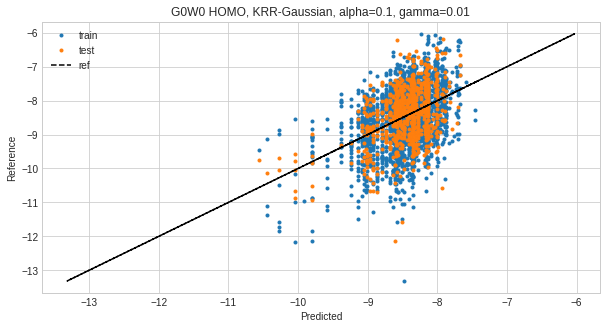

In [145]:
y_pred_tr = optimum.predict(X_tr)
y_pred_cv = optimum.predict(X_cv)

plt.figure(figsize=(10, 5))
plt.title("G0W0 HOMO, KRR-Gaussian, alpha=0.1, gamma=0.01")
plt.plot(y_pred_tr, y_tr, '.', label='train')
plt.plot(y_pred_cv, y_cv, '.', label='test')
plt.plot(y_tr, y_tr, 'k--', label='ref')
plt.xlabel('Predicted')
plt.ylabel('Reference')
plt.legend()
plt.show()

In [151]:
alpha = np.logspace(-2, 2, 5)
gamma = np.logspace(-2, 2, 5)
kernel = 'laplacian'
cv_number = 5
scoring_function = 'neg_mean_absolute_error' 
grid_search = GridSearchCV(KernelRidge(), 
                           [{'kernel':[kernel],'alpha': alpha, 'gamma': gamma}], 
                           cv = cv_number, 
                           scoring = scoring_function,
                           verbose=1000)

from datetime import datetime
start = datetime.now()

grid_search.fit(X_train, y_train)

finish = datetime.now()
total_time = finish - start 
print("It took how long?", total_time)

Fitting 5 folds for each of 25 candidates, totalling 125 fits
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[CV] alpha=0.01, gamma=0.01, kernel=laplacian ........................
[CV]  alpha=0.01, gamma=0.01, kernel=laplacian, score=-0.613, total=   1.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    1.0s remaining:    0.0s
[CV] alpha=0.01, gamma=0.01, kernel=laplacian ........................
[CV]  alpha=0.01, gamma=0.01, kernel=laplacian, score=-0.573, total=   1.0s
[Parallel(n_jobs=1)]: Done   2 out of   2 | elapsed:    2.0s remaining:    0.0s
[CV] alpha=0.01, gamma=0.01, kernel=laplacian ........................
[CV]  alpha=0.01, gamma=0.01, kernel=laplacian, score=-0.612, total=   1.0s
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    3.0s remaining:    0.0s
[CV] alpha=0.01, gamma=0.01, kernel=laplacian ........................
[CV]  alpha=0.01, gamma=0.01, kernel=laplacian, score=-0.591, total=   1.0s
[Parallel(n_jobs=1)]: Done   

In [152]:
optimum = grid_search.best_estimator_

print(F'Optimal alpha value is: {optimum.alpha}')
print(F'Optimal gamma value is: {optimum.gamma}')

Optimal alpha value is: 1.0
Optimal gamma value is: 0.01


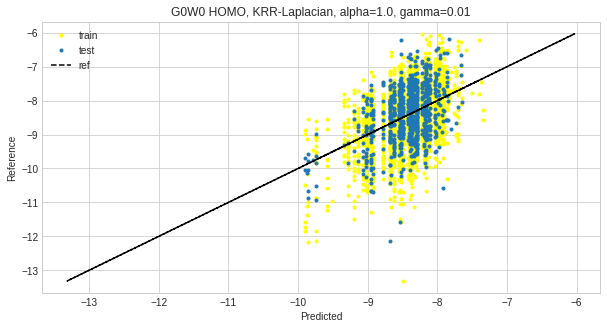

In [154]:
y_pred_tr = optimum.predict(X_tr)
y_pred_cv = optimum.predict(X_cv)

plt.figure(figsize=(10, 5))
plt.title("G0W0 HOMO, KRR-Laplacian, alpha=1.0, gamma=0.01")
plt.plot(y_pred_tr, y_tr, '.', label='train', c = 'yellow')
plt.plot(y_pred_cv, y_cv, '.', label='test')
plt.plot(y_tr, y_tr, 'k--', label='ref')
plt.xlabel('Predicted')
plt.ylabel('Reference')
plt.legend()
plt.show()

NameError: ignored